## Text Classification and Sentiment Analysis:

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [27]:
!pip install wordcloud

In [28]:
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [29]:
df = pd.read_csv('amazonreviews (1).tsv', sep='\t')
df

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [30]:
print(df.head())
print(df.shape)

  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...
(10000, 2)


In [31]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None


In [32]:
##Data cleaning:
df.isnull().sum()

label     0
review    0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

        Missing values were checked and none were found. Duplicate records were also checked and none were found. Therefore, no missing-value handling or duplicate removal was required.

In [34]:
###Text preprocessing:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)
df['clean_review'] = df['review'].apply(preprocess)
print(df[['review', 'clean_review']].head())

                                              review  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   
2  Amazing!: This soundtrack is my favorite music...   
3  Excellent Soundtrack: I truly like this soundt...   
4  Remember, Pull Your Jaw Off The Floor After He...   

                                        clean_review  
0  stuning even non-gamer: sound track beautiful!...  
1  best soundtrack ever anything.: reading lot re...  
2  amazing!: soundtrack favorite music time, hand...  
3  excellent soundtrack: truly like soundtrack en...  
4  remember, pull jaw floor hearing it: played ga...  


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


        The review text was preprocessed by converting all text to lowercase and removing English stopwords using the NLTK stopwords list. A new column named clean_review was created to store the cleaned text.

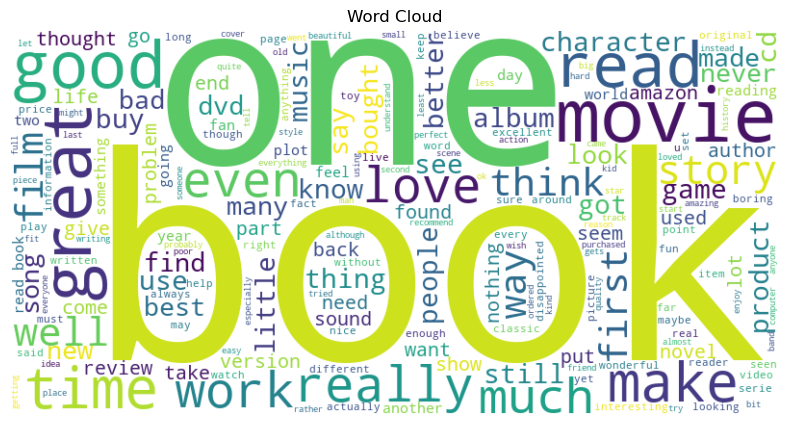

In [35]:
###Exploratory Analysis:
###Word Clouds:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['clean_review'])

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud')
plt.savefig('wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

  The word cloud highlights the most frequently occurring words in customer reviews.

label
neg    5097
pos    4903
Name: count, dtype: int64


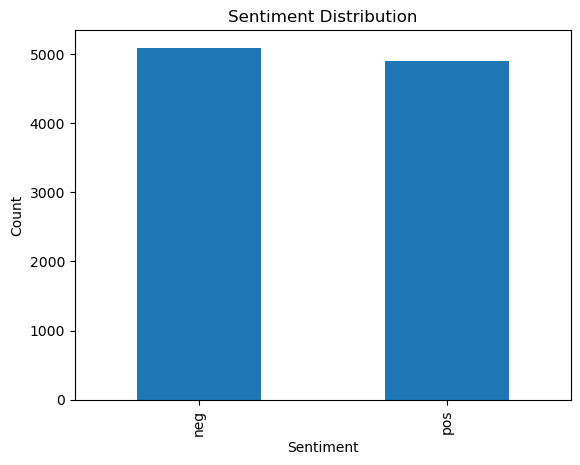

In [36]:
###Sentiment Distribution:
print(df['label'].value_counts())
df['label'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

The bar chart shows the number of positive and negative reviews in the dataset.

Most common positive words:
[('book', 2403), ('great', 1775), ('one', 1594), ('good', 1353), ('like', 1227), ('read', 1167), ('would', 931), ('love', 820), ('really', 814), ('get', 773)]


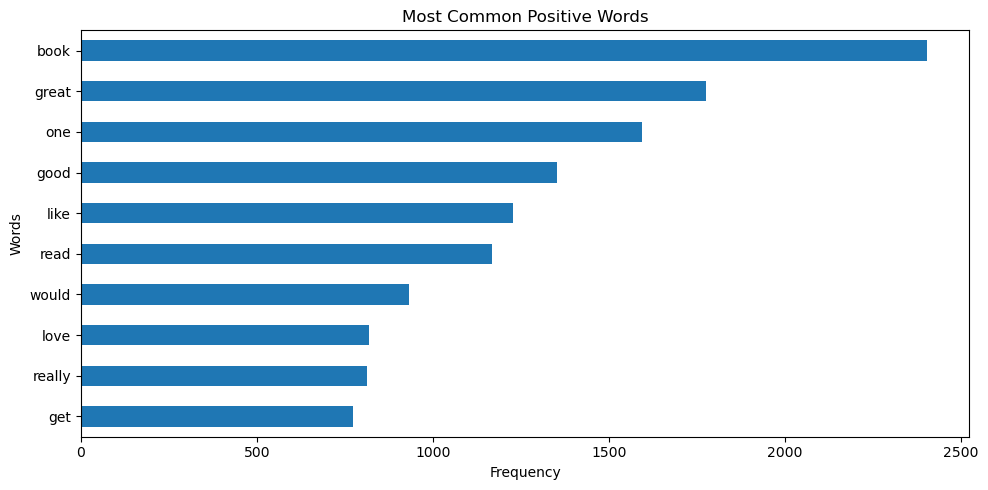

In [42]:
# Most common positive words
positive_words = df[df['label'] == 'pos']['clean_review'].str.split().explode().value_counts().head(10)
print("Most common positive words:")
print(list(positive_words.items()))
plt.figure(figsize=(10, 5))
positive_words.sort_values().plot(kind='barh')
plt.title('Most Common Positive Words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.tight_layout()
plt.savefig('positive_words.png', dpi=300, bbox_inches='tight')
plt.show()

Frequently occurring positive words indicate customer satisfaction and appreciation.

Most common negative words:
[('book', 2316), ('one', 1729), ('like', 1493), ('would', 1427), ('get', 1122), ('movie', 1036), ('read', 954), ('good', 934), ('even', 882), ('it.', 774)]


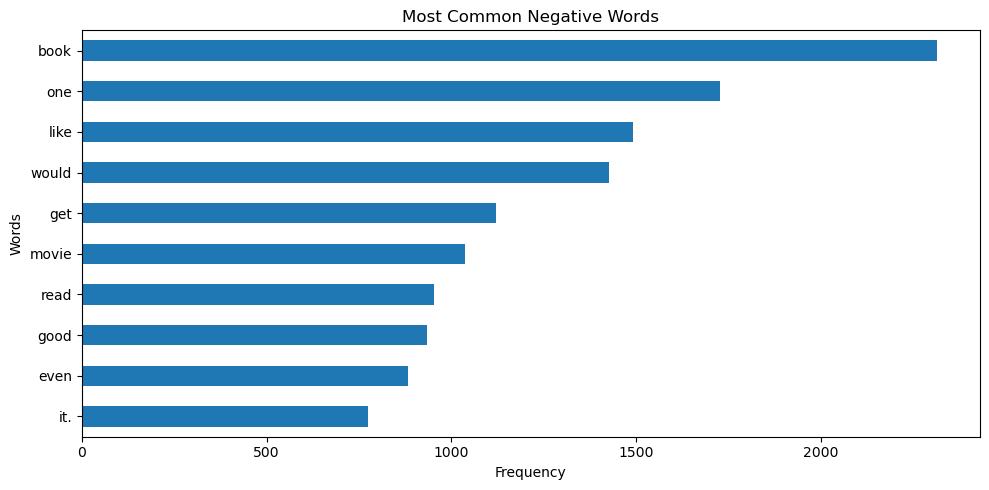

In [43]:
# Most common negative words
negative_words = df[df['label'] == 'neg']['clean_review'].str.split().explode().value_counts().head(10)
print("Most common negative words:")
print(list(negative_words.items()))
plt.figure(figsize=(10, 5))
negative_words.sort_values().plot(kind='barh')
plt.title('Most Common Negative Words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.tight_layout()
plt.savefig('negative_words.png', dpi=300, bbox_inches='tight')
plt.show()

Frequently occurring negative words indicate complaints, dissatisfaction, or product issues.

## Exploratory Analysis:

* The sentiment distribution was visualized using a bar chart to compare the number of positive and negative reviews.
* A word cloud was generated from the cleaned review text to identify frequently used words.
* The most common positive words were extracted from reviews labeled `pos`.
* The most common negative words were extracted from reviews labeled `neg`.
* These analyses provided an initial understanding of customer opinions and common themes in the review dataset.


In [44]:
####Model Development:
####NLP techniques:
###Convert text into numerical features (TF-IDF):
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])
y = df['label']
print(X.shape)

(10000, 5000)


TF-IDF was used to convert the cleaned review text into numerical feature vectors. The vocabulary size was limited to 5000 features.

In [45]:
###Split the dataset:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(8000, 5000)
(2000, 5000)


The dataset was divided into 80% training data and 20% testing data using train_test_split.

In [17]:
####Logistic Regression model:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
print('Model trained successfully')

Model trained successfully


A Logistic Regression classifier was trained on the TF-IDF features to classify reviews as positive or negative.

In [18]:
###Make predictions:
y_pred = model.predict(X_test)
print(y_pred[:10])

['neg' 'neg' 'neg' 'neg' 'pos' 'pos' 'pos' 'neg' 'neg' 'neg']


In [19]:
###Evaluate the model:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.856

Classification Report:

              precision    recall  f1-score   support

         neg       0.86      0.86      0.86      1037
         pos       0.85      0.85      0.85       963

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000


Confusion Matrix:

[[896 141]
 [147 816]]


Model performance was evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

## Model Development:

The cleaned review text was transformed into numerical vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) technique. The resulting feature matrix was divided into training and testing sets in an 80:20 ratio. A Logistic Regression classifier was trained on the training data and used to predict the sentiment labels of the test reviews. Logistic Regression was selected because it is a simple, efficient, and widely used algorithm for text classification tasks.


In [20]:
###Cross Validtion:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean Cross-validation Accuracy:", cv_scores.mean())

Cross-validation scores: [0.8575   0.845625 0.854375 0.8475   0.855625]
Mean Cross-validation Accuracy: 0.852125


## Validation:
The dataset was divided into training and testing sets using an 80:20 split. The Logistic Regression model achieved an accuracy of 85.6% on the test data. The F1-score was 0.86 for negative reviews and 0.85 for positive reviews, indicating good classification performance. Five-fold cross-validation was also performed, resulting in a mean accuracy of 85.21%. These results show that the model provides consistent and reliable sentiment classification performance.

## Conclusion:

The sentiment analysis model was developed to classify Amazon customer reviews as positive or negative. The review text was cleaned and preprocessed, and TF-IDF was used to convert the text into numerical features. A Logistic Regression model was then trained for sentiment classification.

The model achieved an accuracy of **85.6%** on the test data. The F1-score was **0.86 for negative reviews** and **0.85 for positive reviews**. Five-fold cross-validation produced a mean accuracy of **85.21%**, showing consistent model performance.

Overall, the results indicate that the TF-IDF and Logistic Regression approach can effectively classify customer reviews into positive and negative sentiments.
